# EEEM068 - Multi-View ViT-Small + SiT-S - Part 5

**Scope:** Checkpoint loading, evaluation, attention rollout, internet image testing, domain shift, and final summary

**Source notebook:** `EEEM068_SiT_S_Final_FIXED (2).ipynb`

**Notes**
- This notebook is a split component of the original final notebook.
- Some setup cells are intentionally repeated so each part is easier to understand in isolation.
- If you want to run the full pipeline end-to-end, use the original notebook or follow the README in sequence.

# EEEM068 — Knee MRI Classification · ViT-Small + SiT-S
**University of Surrey — Applied Machine Learning (Spring 2026)**

| Item | Detail |
|---|---|
| Model | Multi-View ViT-Small patch16/224 (shared backbone, 3 planes) |
| Pretrained weights | **SiT-S** — Sara Ahmed et al. 2021 (self-supervised ImageNet) |
| Dataset | MRNet — 1,370 knee MRI exams (Stanford University Medical Center) |
| Task | Multi-label: ACL tear · Meniscus tear · Abnormal |
| Loss | Focal BCE (γ=0.5) + Label smoothing + MixUp |

**Run order:** Execute cells top-to-bottom. Edit only the two paths in Section 1.

---


## Section 1 — Imports & Configuration

In [1]:
import os, io, gc, math, pickle, random, warnings, urllib.request
from pathlib import Path
from io import BytesIO
from collections import deque, OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as T
import timm

warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

print(f"PyTorch : {torch.__version__}")
print(f"timm    : {timm.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


PyTorch : 2.11.0+cu130
timm    : 1.0.27
CUDA    : True
GPU     : NVIDIA RTX A4000
VRAM    : 16.7 GB


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — fixed for your Surrey/otter AML folder
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    # ── MAIN PROJECT PATHS ────────────────────────────────────────────────────
    AML_DIR = Path("/user/HS402/mi00806/Downloads/AML")

    ROOT    = Path("/user/HS402/mi00806/.cache/kagglehub/datasets/"
                   "cjinny/mrnet-v1/versions/1/MRNet-v1.0")
    OUT_DIR = AML_DIR / "mrnet_outputs"

    # Your real downloaded SiT-S checkpoints are inside AML/sit_zip/
    SIT_DIR = AML_DIR / "sit_zip"
    SIT_VARIANT = "ImageNet"   # options: ImageNet, Pascal, Pets, STL10
    SIT_CACHE_PATH = str(SIT_DIR / f"SiT_Small_{SIT_VARIANT}.pth")

    CHECKPOINT_PATH = str(OUT_DIR / "best_vit.pth")
    TENSORBOARD_DIR = str(OUT_DIR / "tb_logs")

    IMAGE_SIZE  = 224
    MODEL_NAME  = "vit_small_patch16_224"
    NUM_CLASSES = 3
    LABEL_NAMES = ["acl", "meniscus", "abnormal"]

    TOP_K_SLICES = 5
    N_CHANNELS   = 3

    BATCH_SIZE  = 8
    EPOCHS      = 60
    MIN_EPOCHS  = 20
    PATIENCE    = 15
    NUM_WORKERS = 4
    SEED        = 42

    HEAD_LR           = 1e-3
    BACKBONE_LR_LATE  = 1e-5
    BACKBONE_LR_EARLY = 5e-6
    WEIGHT_DECAY      = 1e-4

    UNFREEZE_PARTIAL_EP = 5
    UNFREEZE_FULL_EP    = 10
    N_BLOCKS_PARTIAL    = 6
    WARMUP_EPOCHS       = 3
    WARMUP_RESTART      = 2

    DROP_PATH_RATE = 0.1
    DROPOUT_HEAD1  = 0.3
    DROPOUT_HEAD2  = 0.15
    LABEL_SMOOTH   = 0.05
    MIXUP_ALPHA    = 0.2
    MIXUP_PROB     = 0.4
    MIXUP_START_EP = UNFREEZE_PARTIAL_EP + 1

    FOCAL_GAMMA = 0.5
    FOCAL_ALPHA = [0.82, 0.63, 0.19]

    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CFG.OUT_DIR.mkdir(parents=True, exist_ok=True)

assert CFG.ROOT.exists(), f"Dataset not found: {CFG.ROOT}"
assert Path(CFG.SIT_CACHE_PATH).exists(), (
    f"SiT checkpoint not found: {CFG.SIT_CACHE_PATH}\n"
    f"Your downloaded files should be in: {CFG.SIT_DIR}\n"
    "Run: ls -lh /user/HS402/mi00806/Downloads/AML/sit_zip/"
)

print("CFG loaded ✅")
print(f"  Device     : {CFG.DEVICE}")
print(f"  Dataset    : {CFG.ROOT}")
print(f"  Out dir    : {CFG.OUT_DIR}")
print(f"  SiT weights: {CFG.SIT_CACHE_PATH}")
print(f"  SiT size   : {Path(CFG.SIT_CACHE_PATH).stat().st_size/1e6:.1f} MB")


CFG loaded ✅
  Device     : cuda
  Dataset    : /user/HS402/mi00806/.cache/kagglehub/datasets/cjinny/mrnet-v1/versions/1/MRNet-v1.0
  Out dir    : /user/HS402/mi00806/Downloads/AML/mrnet_outputs
  SiT weights: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
  SiT size   : 669.7 MB


## Section 2 — SiT-S Weights: Load Local Checkpoint

This version is fixed for your current folder structure.

Your real checkpoint files are already downloaded in:

```text
/user/HS402/mi00806/Downloads/AML/sit_zip/
```

The notebook now loads:

```text
SiT_Small_ImageNet.pth
```

So it will no longer look for the missing `../sit_extracted/` folder.


In [3]:
# ── SiT-S checkpoint load from your local sit_zip folder ──────────────────────
# Your downloaded files:
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_Pascal.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_Pets.pth
#   /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_STL10.pth

SIT_CACHE = Path(CFG.SIT_CACHE_PATH)


def load_sit_checkpoint(path):
    """Load a local SiT checkpoint safely."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    size_mb = path.stat().st_size / 1e6
    print(f"  File: {path}")
    print(f"  Size: {size_mb:.1f} MB")

    if size_mb < 100:
        raise RuntimeError(
            f"This checkpoint is too small ({size_mb:.1f} MB).\n"
            "Use the real downloaded checkpoint in AML/sit_zip/, not data.pkl or sit_small.pth."
        )

    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    print("  ✅ torch.load: OK")
    return ckpt


def extract_sit_state_dict(ckpt, ref_keys):
    """Find and clean the state dict from the SiT checkpoint."""
    ref_keys = set(ref_keys)

    candidates = {}
    if isinstance(ckpt, dict):
        for k in ["student", "teacher", "model", "state_dict", "module", "backbone"]:
            if k in ckpt and isinstance(ckpt[k], dict):
                candidates[k] = ckpt[k]
        if not candidates:
            candidates["<root>"] = ckpt
    else:
        raise TypeError(f"Unexpected checkpoint type: {type(ckpt)}")

    best_n, best_key, best_state = 0, None, None

    prefixes = [
        "module.backbone.",
        "module.student.backbone.",
        "student.backbone.",
        "teacher.backbone.",
        "backbone.",
        "module.",
    ]

    for key, state in candidates.items():
        cleaned = {}
        for k, v in state.items():
            new_k = k
            for prefix in prefixes:
                if new_k.startswith(prefix):
                    new_k = new_k[len(prefix):]
            cleaned[new_k] = v

        n = len(ref_keys & set(cleaned.keys()))
        print(f"  key='{key}': {n}/{len(ref_keys)} keys match timm ViT-Small")

        if n > best_n:
            best_n, best_key, best_state = n, key, cleaned

    return best_key, best_state, best_n


def check_nan(state_dict):
    """Return list of keys with NaN values."""
    nan_keys = []
    for k, v in state_dict.items():
        if torch.is_tensor(v) and torch.isnan(v.float()).any():
            nan_keys.append(k)
    return nan_keys


# ── STEP 1: Use local checkpoint ──────────────────────────────────────────────
print("=" * 60)
print("STEP 1 — Using local SiT-S checkpoint")
print("=" * 60)
print(f"✅ Using: {SIT_CACHE}")

# ── STEP 2: Load and inspect ─────────────────────────────────────────────────
print()
print("=" * 60)
print("STEP 2 — Loading and inspecting checkpoint")
print("=" * 60)

raw_ckpt = load_sit_checkpoint(SIT_CACHE)
if isinstance(raw_ckpt, dict):
    print(f"Top-level keys: {list(raw_ckpt.keys())[:20]}")
    if "epoch" in raw_ckpt:
        print(f"Saved at epoch: {raw_ckpt['epoch']}")

# ── STEP 3: Build reference model and match keys ──────────────────────────────
print()
print("=" * 60)
print("STEP 3 — Matching keys to timm ViT-Small")
print("=" * 60)

_ref = timm.create_model(CFG.MODEL_NAME, pretrained=False, num_classes=0)
ref_keys = list(_ref.state_dict().keys())
print(f"timm ViT-Small has {len(ref_keys)} parameter tensors")

best_key, best_state, n_matched = extract_sit_state_dict(raw_ckpt, ref_keys)
del _ref

print(f"\nBest match: key='{best_key}'  {n_matched}/{len(ref_keys)} keys matched")

# ── STEP 4: Check health ─────────────────────────────────────────────────────
print()
print("=" * 60)
print("STEP 4 — NaN / health check")
print("=" * 60)

if best_state is not None and n_matched > 10:
    nan_keys = check_nan(best_state)
    print(f"NaN tensors: {len(nan_keys)} / {len(best_state)}")

    if nan_keys:
        print(f"NaN keys first 5: {nan_keys[:5]}")
        SIT_WEIGHTS_OK = False
        print("⚠️ SiT weights are not healthy, notebook will fall back to timm ImageNet.")
    else:
        SIT_WEIGHTS_OK = True
        print("✅ SiT checkpoint is healthy and ready to load")
else:
    SIT_WEIGHTS_OK = False
    print(f"⚠️ Only {n_matched} keys matched — notebook will fall back to timm ImageNet.")

print(f"\nSIT_WEIGHTS_OK = {SIT_WEIGHTS_OK}")


STEP 1 — Using local SiT-S checkpoint
✅ Using: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth

STEP 2 — Loading and inspecting checkpoint
  File: /user/HS402/mi00806/Downloads/AML/sit_zip/SiT_Small_ImageNet.pth
  Size: 669.7 MB
  ✅ torch.load: OK
Top-level keys: ['student', 'teacher', 'optimizer', 'epoch', 'args', 'fp16_scaler']
Saved at epoch: 715

STEP 3 — Matching keys to timm ViT-Small
timm ViT-Small has 150 parameter tensors
  key='student': 150/150 keys match timm ViT-Small
  key='teacher': 150/150 keys match timm ViT-Small

Best match: key='student'  150/150 keys matched

STEP 4 — NaN / health check
NaN tensors: 0 / 177
✅ SiT checkpoint is healthy and ready to load

SIT_WEIGHTS_OK = True


## Section 3 — Model: MultiViewViT

**Architecture:** One shared ViT-Small backbone processes all three MRI planes
independently. Each plane produces a 384-dim CLS token. Three tokens are
concatenated → 1152-dim → MLP head → 3 output logits.

**Weight loading priority:**
1. SiT-S from Sara Ahmed et al. (self-supervised ImageNet, recommended by spec)
2. timm supervised ImageNet (fallback if SiT download fails)

The model clearly reports which source was used via `model.pretrained_source`.


In [4]:
class MultiViewViT(nn.Module):
    """Multi-view ViT-Small for knee MRI multi-label classification.

    One shared backbone encodes sagittal, coronal and axial planes independently.
    CLS outputs [B,384] x3 concatenated to [B,1152] → MLP head → [B,3] logits.
    """

    def __init__(self, num_classes=CFG.NUM_CLASSES):
        super().__init__()
        self.backbone = timm.create_model(
            CFG.MODEL_NAME, pretrained=False, num_classes=0,
            drop_path_rate=CFG.DROP_PATH_RATE
        )
        D = self.backbone.num_features  # 384 for ViT-Small

        self.head = nn.Sequential(
            nn.LayerNorm(D * 3),
            nn.Linear(D * 3, 512), nn.GELU(), nn.Dropout(CFG.DROPOUT_HEAD1),
            nn.Linear(512, 256),   nn.GELU(), nn.Dropout(CFG.DROPOUT_HEAD2),
            nn.Linear(256, num_classes),
        )
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, sag, cor, axi):
        feats = torch.cat([self.backbone(sag),
                           self.backbone(cor),
                           self.backbone(axi)], dim=1)
        return self.head(feats)

    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False

    def unfreeze_last_n_blocks(self, n):
        for p in self.backbone.parameters(): p.requires_grad = False
        for block in list(self.backbone.blocks)[-n:]:
            for p in block.parameters(): p.requires_grad = True
        for p in self.backbone.norm.parameters(): p.requires_grad = True

    def unfreeze_all(self):
        for p in self.backbone.parameters(): p.requires_grad = True

    def trainable_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def get_param_groups(self, head_lr, bb_early_lr, bb_late_lr, wd):
        blocks       = list(self.backbone.blocks)
        half         = len(blocks) // 2
        early_params = [p for b in blocks[:half] for p in b.parameters()]
        late_params  = [p for b in blocks[half:] for p in b.parameters()]
        extra_early  = (list(self.backbone.patch_embed.parameters()) +
                        [self.backbone.cls_token, self.backbone.pos_embed])
        return [
            {"params": self.head.parameters(),
             "lr": head_lr,     "weight_decay": wd},
            {"params": late_params + list(self.backbone.norm.parameters()),
             "lr": bb_late_lr,  "weight_decay": wd},
            {"params": early_params + extra_early,
             "lr": bb_early_lr, "weight_decay": wd},
        ]


# ── Build model ───────────────────────────────────────────────────────────────
model = MultiViewViT().to(CFG.DEVICE)

if SIT_WEIGHTS_OK and best_state is not None:
    # ── Load SiT-S weights ─────────────────────────────────────────────────────
    msg = model.backbone.load_state_dict(best_state, strict=False)
    model.pretrained_source = "SiT-S (Sara Ahmed et al. 2021, self-supervised ImageNet)"
    print(f"✅ SiT-S weights loaded")
    print(f"   Matched   : {n_matched}/{len(ref_keys)}")
    print(f"   Missing   : {len(msg.missing_keys)}")
    print(f"   Unexpected: {len(msg.unexpected_keys)}")
else:
    # ── Fallback: timm supervised ImageNet ────────────────────────────────────
    print("Loading timm supervised ImageNet weights (SiT-S unavailable)...")
    sup = timm.create_model(CFG.MODEL_NAME, pretrained=True, num_classes=0,
                            drop_path_rate=CFG.DROP_PATH_RATE)
    model.backbone.load_state_dict(sup.state_dict(), strict=True)
    del sup
    model.pretrained_source = "timm supervised ImageNet (SiT-S download failed)"
    print(f"⚠️  Using ImageNet weights — see Section 2 to fix SiT-S download")

# ── Assert zero NaN weights ───────────────────────────────────────────────────
nan_count = sum(1 for p in model.parameters() if p.isnan().any())
assert nan_count == 0, (
    f"{nan_count} NaN parameter tensors detected — "
    "weights did not load correctly. Re-run Section 2."
)

# ── Forward pass sanity check ─────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    x     = torch.randn(2, 3, 224, 224).to(CFG.DEVICE)
    probs = torch.sigmoid(model(x, x, x))
    mean_p = probs.mean().item()

print(f"\nPretrained source : {model.pretrained_source}")
print(f"Total parameters  : {sum(p.numel() for p in model.parameters()):,}")
print(f"Forward pass probs: {probs.cpu().numpy().round(3)}")
if 0.05 < mean_p < 0.95:
    print(f"✅ mean prob = {mean_p:.3f} — healthy")
else:
    print(f"⚠️  mean prob = {mean_p:.3f} — COLLAPSED — weights broken")


✅ SiT-S weights loaded
   Matched   : 150/150
   Missing   : 0
   Unexpected: 27

Pretrained source : SiT-S (Sara Ahmed et al. 2021, self-supervised ImageNet)
Total parameters  : 22,390,403
Forward pass probs: [[0.322 0.431 0.495]
 [0.326 0.435 0.49 ]]
✅ mean prob = 0.416 — healthy


## Section 4 — Dataset Labels & Stratified Split

MRNet provides three CSV files (one per condition) for the train split.
Labels: ACL tear, Meniscus tear, Abnormal (multi-label — not mutually exclusive).
We perform a **stratified 85/15 split** on the `abnormal` label.


In [5]:
def load_labels(root, split):
    """Load and merge ACL / Abnormal / Meniscus CSVs into one DataFrame."""
    acl      = pd.read_csv(root / f"{split}-acl.csv",
                           header=None, names=["id", "acl"])
    abnormal = pd.read_csv(root / f"{split}-abnormal.csv",
                           header=None, names=["id", "abnormal"])
    meniscus = pd.read_csv(root / f"{split}-meniscus.csv",
                           header=None, names=["id", "meniscus"])
    df = acl.merge(abnormal, on="id").merge(meniscus, on="id")
    df["id"] = df["id"].astype(str).str.zfill(4)
    for plane in ["sagittal", "coronal", "axial"]:
        df[f"{plane}_path"] = df["id"].apply(
            lambda x, p=plane: str(root / "train" / p / f"{x}.npy"))
    df["target"] = df.apply(
        lambda r: [float(r["acl"]),
                   float(r["meniscus"]),
                   float(r["abnormal"])], axis=1)
    return df


all_df = load_labels(CFG.ROOT, "train")
train_df, valid_df = train_test_split(
    all_df, test_size=0.15, random_state=CFG.SEED,
    stratify=all_df["abnormal"].astype(int)
)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print(f"Train : {len(train_df)} scans")
print(f"Valid : {len(valid_df)} scans  (15% stratified split)")
print()
print("Label distribution:")
for lbl in CFG.LABEL_NAMES:
    tr_n = int(train_df[lbl].sum())
    va_n = int(valid_df[lbl].sum())
    print(f"  {lbl:>10}:  "
          f"train {tr_n:>3} pos ({100*tr_n/len(train_df):.1f}%)  "
          f"| valid {va_n:>3} pos ({100*va_n/len(valid_df):.1f}%)")


Train : 960 scans
Valid : 170 scans  (15% stratified split)

Label distribution:
         acl:  train 185 pos (19.3%)  | valid  23 pos (13.5%)
    meniscus:  train 328 pos (34.2%)  | valid  69 pos (40.6%)
    abnormal:  train 776 pos (80.8%)  | valid 137 pos (80.6%)


## Section 6 — Preprocessing & Dataset Class

**Slice selection:** Top-5 variance slices selected per volume → 3 chosen
evenly → stacked as pseudo-RGB image. High-variance slices contain structural
detail rather than blank background.

**Augmentation (train only):** rotation ±20°, translation ±10%,
scale 85–115%, horizontal flip, colour jitter.


In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def select_topk_variance_slices(volume, top_k=5, n_out=3):
    D   = volume.shape[0]
    var = np.var(volume.reshape(D,-1), axis=1)
    topk = np.sort(np.argsort(var)[-min(top_k,D):])
    n_out = min(n_out, len(topk))
    chosen = topk[np.linspace(0, len(topk)-1, n_out, dtype=int)]
    if len(chosen) < n_out:
        chosen = np.pad(chosen, (0, n_out-len(chosen)), mode="edge")
    return volume[chosen]


def volume_to_rgb(volume, top_k=5, n_ch=3):
    slices = select_topk_variance_slices(volume, top_k=top_k, n_out=n_ch)
    channels = []
    for s in slices:
        s = s.astype(np.float32)
        lo, hi = s.min(), s.max()
        s = (s-lo)/(hi-lo+1e-8)
        channels.append((s*255).clip(0,255).astype(np.uint8))
    return Image.fromarray(np.stack(channels, axis=-1))


train_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.RandomAffine(degrees=20, translate=(0.10,0.10), scale=(0.85,1.15), fill=0),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.25, contrast=0.25),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
valid_tfm = T.Compose([
    T.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MRNetDataset(Dataset):
    """Loads sag/cor/axi volumes and returns 3 pseudo-RGB tensors + target."""
    def __init__(self, df, transforms=None, top_k=5, n_ch=3):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.top_k = top_k; self.n_ch = n_ch

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        imgs = {}
        for plane in ["sagittal","coronal","axial"]:
            vol = np.load(row[f"{plane}_path"], mmap_mode="r")
            img = volume_to_rgb(vol, top_k=self.top_k, n_ch=self.n_ch)
            if self.transforms: img = self.transforms(img)
            imgs[plane] = img
        target = torch.tensor(row["target"], dtype=torch.float32)
        return imgs["sagittal"], imgs["coronal"], imgs["axial"], target, row["id"]


s, c, a, t, eid = MRNetDataset(train_df.head(2), transforms=train_tfm)[0]
print(f"Tensor shape : {tuple(s.shape)}")
print(f"Target       : {t.tolist()}")
print(f"Exam ID      : {eid}")
print("Preprocessing ready ✅")


Tensor shape : (3, 224, 224)
Target       : [0.0, 1.0, 1.0]
Exam ID      : 0104
Preprocessing ready ✅


## Section 13 — Evaluation

Loads best checkpoint. Uses **saved per-label thresholds** for consistent evaluation.
Metrics: Accuracy, Sensitivity, Specificity, Precision, F1, AUC-ROC.


In [15]:
ckpt = torch.load(CFG.CHECKPOINT_PATH, map_location=CFG.DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.unfreeze_all(); model.eval()
eval_threshs = ckpt.get("best_threshs", [0.5,0.5,0.5])

print(f"Loaded epoch {ckpt['epoch']}  val_F1={ckpt['val_f1']:.4f}")
print(f"Pretrained : {ckpt.get('pretrained_source', model.pretrained_source)}")
print("Thresholds : " +
      "  ".join(f"{CFG.LABEL_NAMES[i]}@{eval_threshs[i]:.2f}" for i in range(3)))

all_probs, all_targets = [], []
with torch.no_grad():
    for sag, cor, axi, targets, _ in valid_loader:
        sag, cor, axi = sag.to(CFG.DEVICE), cor.to(CFG.DEVICE), axi.to(CFG.DEVICE)
        probs = torch.sigmoid(model(sag, cor, axi)).cpu().numpy()
        all_probs.append(probs); all_targets.append(targets.numpy())

y_probs = np.vstack(all_probs)
y_true  = np.vstack(all_targets)
y_preds = np.zeros_like(y_probs, dtype=int)
for i, thresh in enumerate(eval_threshs):
    y_preds[:,i] = (y_probs[:,i]>=thresh).astype(int)

print("\nMean predicted probabilities:")
for i, name in enumerate(CFG.LABEL_NAMES):
    print(f"  {name:>10}: mean={y_probs[:,i].mean():.3f}  "
          f"pred_pos={y_preds[:,i].sum():<4}  actual_pos={int(y_true[:,i].sum())}")

print()
for i, name in enumerate(CFG.LABEL_NAMES):
    print(f"--- {name.upper()} (thresh={eval_threshs[i]:.2f}) ---")
    print(classification_report(y_true[:,i], y_preds[:,i],
          target_names=["Negative","Positive"], digits=4))


Loaded epoch 15  val_F1=0.7428
Pretrained : SiT-S (Sara Ahmed et al. 2021, self-supervised ImageNet)
Thresholds : acl@0.85  meniscus@0.70  abnormal@0.20

Mean predicted probabilities:
         acl: mean=0.523  pred_pos=30    actual_pos=23
    meniscus: mean=0.657  pred_pos=99    actual_pos=69
    abnormal: mean=0.788  pred_pos=153   actual_pos=137

--- ACL (thresh=0.85) ---
              precision    recall  f1-score   support

    Negative     0.9429    0.8980    0.9199       147
    Positive     0.5000    0.6522    0.5660        23

    accuracy                         0.8647       170
   macro avg     0.7214    0.7751    0.7429       170
weighted avg     0.8829    0.8647    0.8720       170

--- MENISCUS (thresh=0.70) ---
              precision    recall  f1-score   support

    Negative     0.9014    0.6337    0.7442       101
    Positive     0.6263    0.8986    0.7381        69

    accuracy                         0.7412       170
   macro avg     0.7638    0.7661    0.7411    

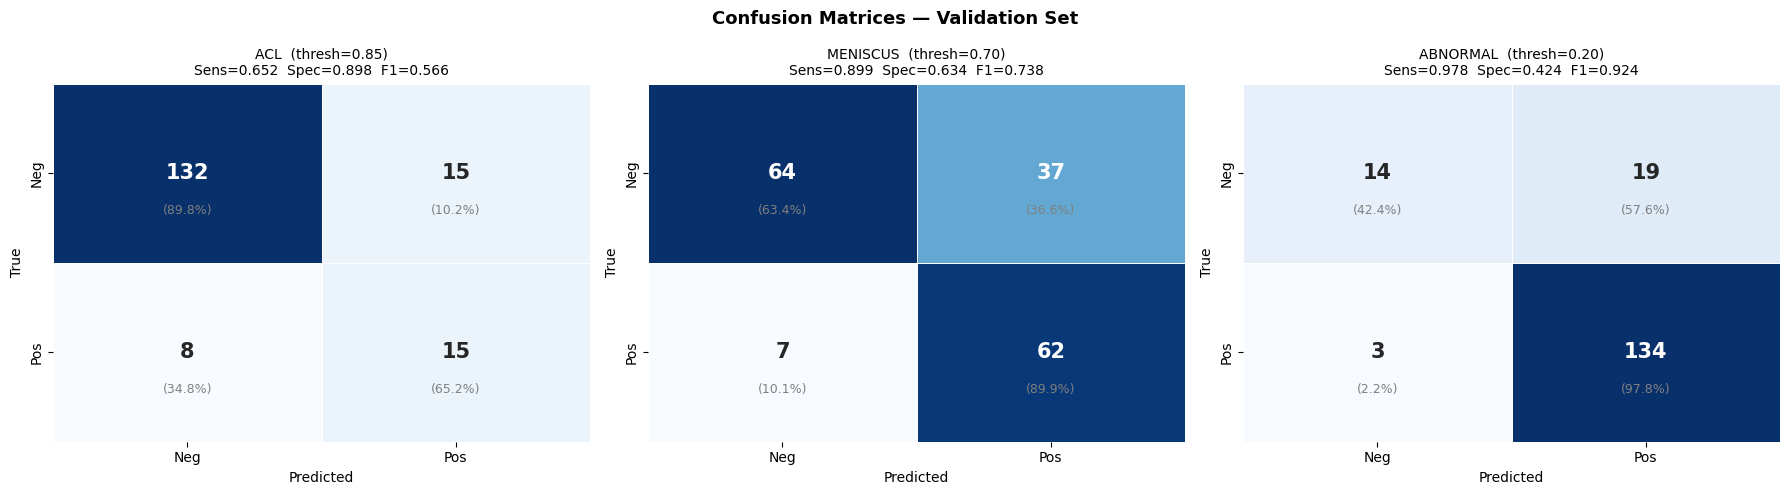

Saved → /user/HS402/mi00806/Downloads/AML/mrnet_outputs/confusion_matrices.png


In [16]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle("Confusion Matrices — Validation Set", fontsize=13, fontweight="bold")

for i, (ax, name) in enumerate(zip(axes, CFG.LABEL_NAMES)):
    cm_raw  = confusion_matrix(y_true[:,i], y_preds[:,i])
    cm_norm = cm_raw.astype(float)/cm_raw.sum(axis=1, keepdims=True)
    sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"],
                linewidths=0.5, cbar=False, annot_kws={"size":15,"weight":"bold"})
    for (r,c), v in np.ndenumerate(cm_raw):
        ax.text(c+0.5, r+0.73, f"({100*cm_norm[r,c]:.1f}%)",
                ha="center", fontsize=9, color="gray")
    tn,fp,fn,tp = cm_raw.ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    f1_i = f1_score(y_true[:,i], y_preds[:,i], zero_division=0)
    ax.set_title(f"{name.upper()}  (thresh={eval_threshs[i]:.2f})\n"
                 f"Sens={sens:.3f}  Spec={spec:.3f}  F1={f1_i:.3f}", fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(CFG.OUT_DIR/"confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {CFG.OUT_DIR/'confusion_matrices.png'}")


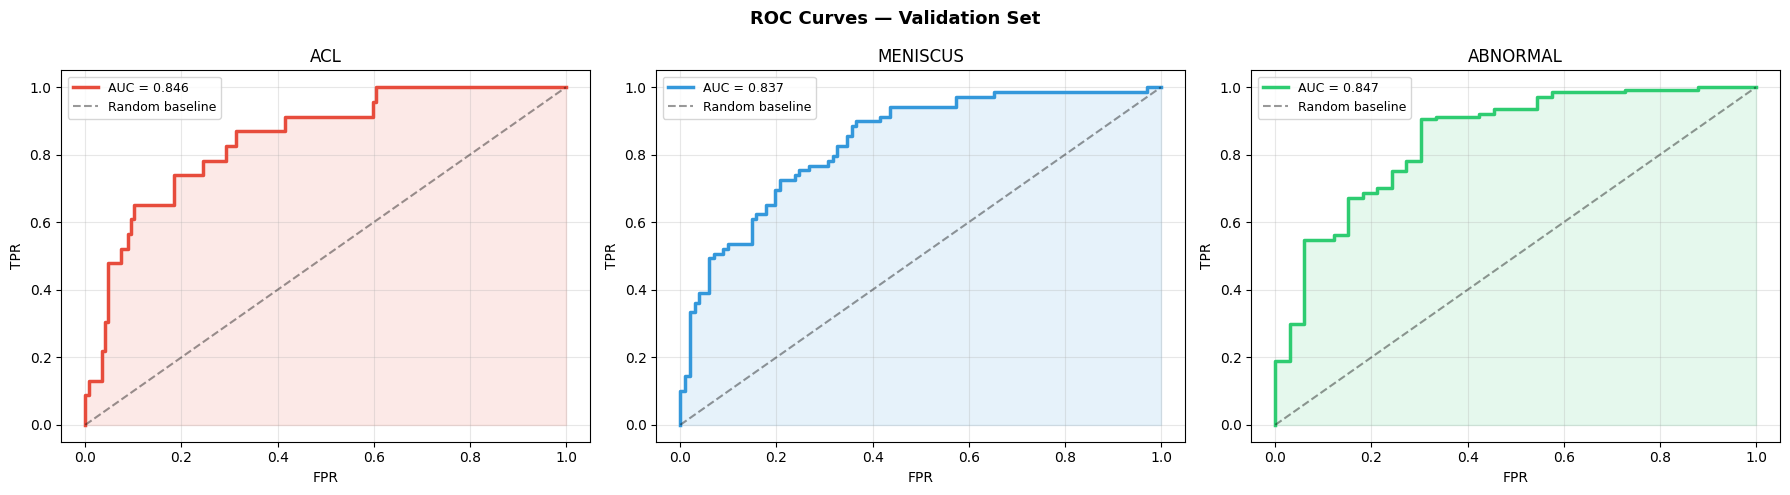

In [17]:
# ROC curves
fig, axes = plt.subplots(1, 3, figsize=(18,5))
fig.suptitle("ROC Curves — Validation Set", fontsize=13, fontweight="bold")

for i, (ax, name, col) in enumerate(zip(axes, CFG.LABEL_NAMES,
                                         ["#E74C3C","#3498DB","#2ECC71"])):
    fpr, tpr, _ = roc_curve(y_true[:,i], y_probs[:,i])
    auc_val = roc_auc_score(y_true[:,i], y_probs[:,i])
    ax.plot(fpr, tpr, color=col, lw=2.5, label=f"AUC = {auc_val:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.12, color=col)
    ax.plot([0,1],[0,1],"k--",alpha=0.4,label="Random baseline")
    ax.set_title(name.upper()); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(CFG.OUT_DIR/"roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [18]:
# Summary table
rows = []
for i, name in enumerate(CFG.LABEL_NAMES):
    tn,fp,fn,tp = confusion_matrix(y_true[:,i], y_preds[:,i]).ravel()
    rows.append({
        "Condition"   : name.upper(),
        "Threshold"   : f"{eval_threshs[i]:.2f}",
        "Accuracy"    : accuracy_score(y_true[:,i], y_preds[:,i]),
        "Sensitivity" : tp/(tp+fn) if (tp+fn)>0 else 0,
        "Specificity" : tn/(tn+fp) if (tn+fp)>0 else 0,
        "Precision"   : tp/(tp+fp) if (tp+fp)>0 else 0,
        "F1-Score"    : f1_score(y_true[:,i], y_preds[:,i], zero_division=0),
        "AUC-ROC"     : roc_auc_score(y_true[:,i], y_probs[:,i]),
    })
rows.append({
    "Condition":"MACRO AVG","Threshold":"-",
    **{k: np.mean([r[k] for r in rows])
       for k in ["Accuracy","Sensitivity","Specificity",
                 "Precision","F1-Score","AUC-ROC"]}
})
summary_df = pd.DataFrame(rows)
print("="*80)
print("TABLE 1 — Evaluation Metrics on Validation Set")
print("="*80)
print(summary_df.to_string(index=False, float_format="{:.4f}".format))
print("="*80)
summary_df.to_csv(CFG.OUT_DIR/"summary_metrics.csv", index=False)
print(f"Saved → {CFG.OUT_DIR/'summary_metrics.csv'}")


TABLE 1 — Evaluation Metrics on Validation Set
Condition Threshold  Accuracy  Sensitivity  Specificity  Precision  F1-Score  AUC-ROC
      ACL      0.85    0.8647       0.6522       0.8980     0.5000    0.5660   0.8459
 MENISCUS      0.70    0.7412       0.8986       0.6337     0.6263    0.7381   0.8373
 ABNORMAL      0.20    0.8706       0.9781       0.4242     0.8758    0.9241   0.8474
MACRO AVG         -    0.8255       0.8429       0.6520     0.6674    0.7428   0.8435
Saved → /user/HS402/mi00806/Downloads/AML/mrnet_outputs/summary_metrics.csv


## Section 14 — Class Attention Rollout

Traces CLS token attention through all 12 transformer layers.
Green title = correct prediction, red = incorrect.


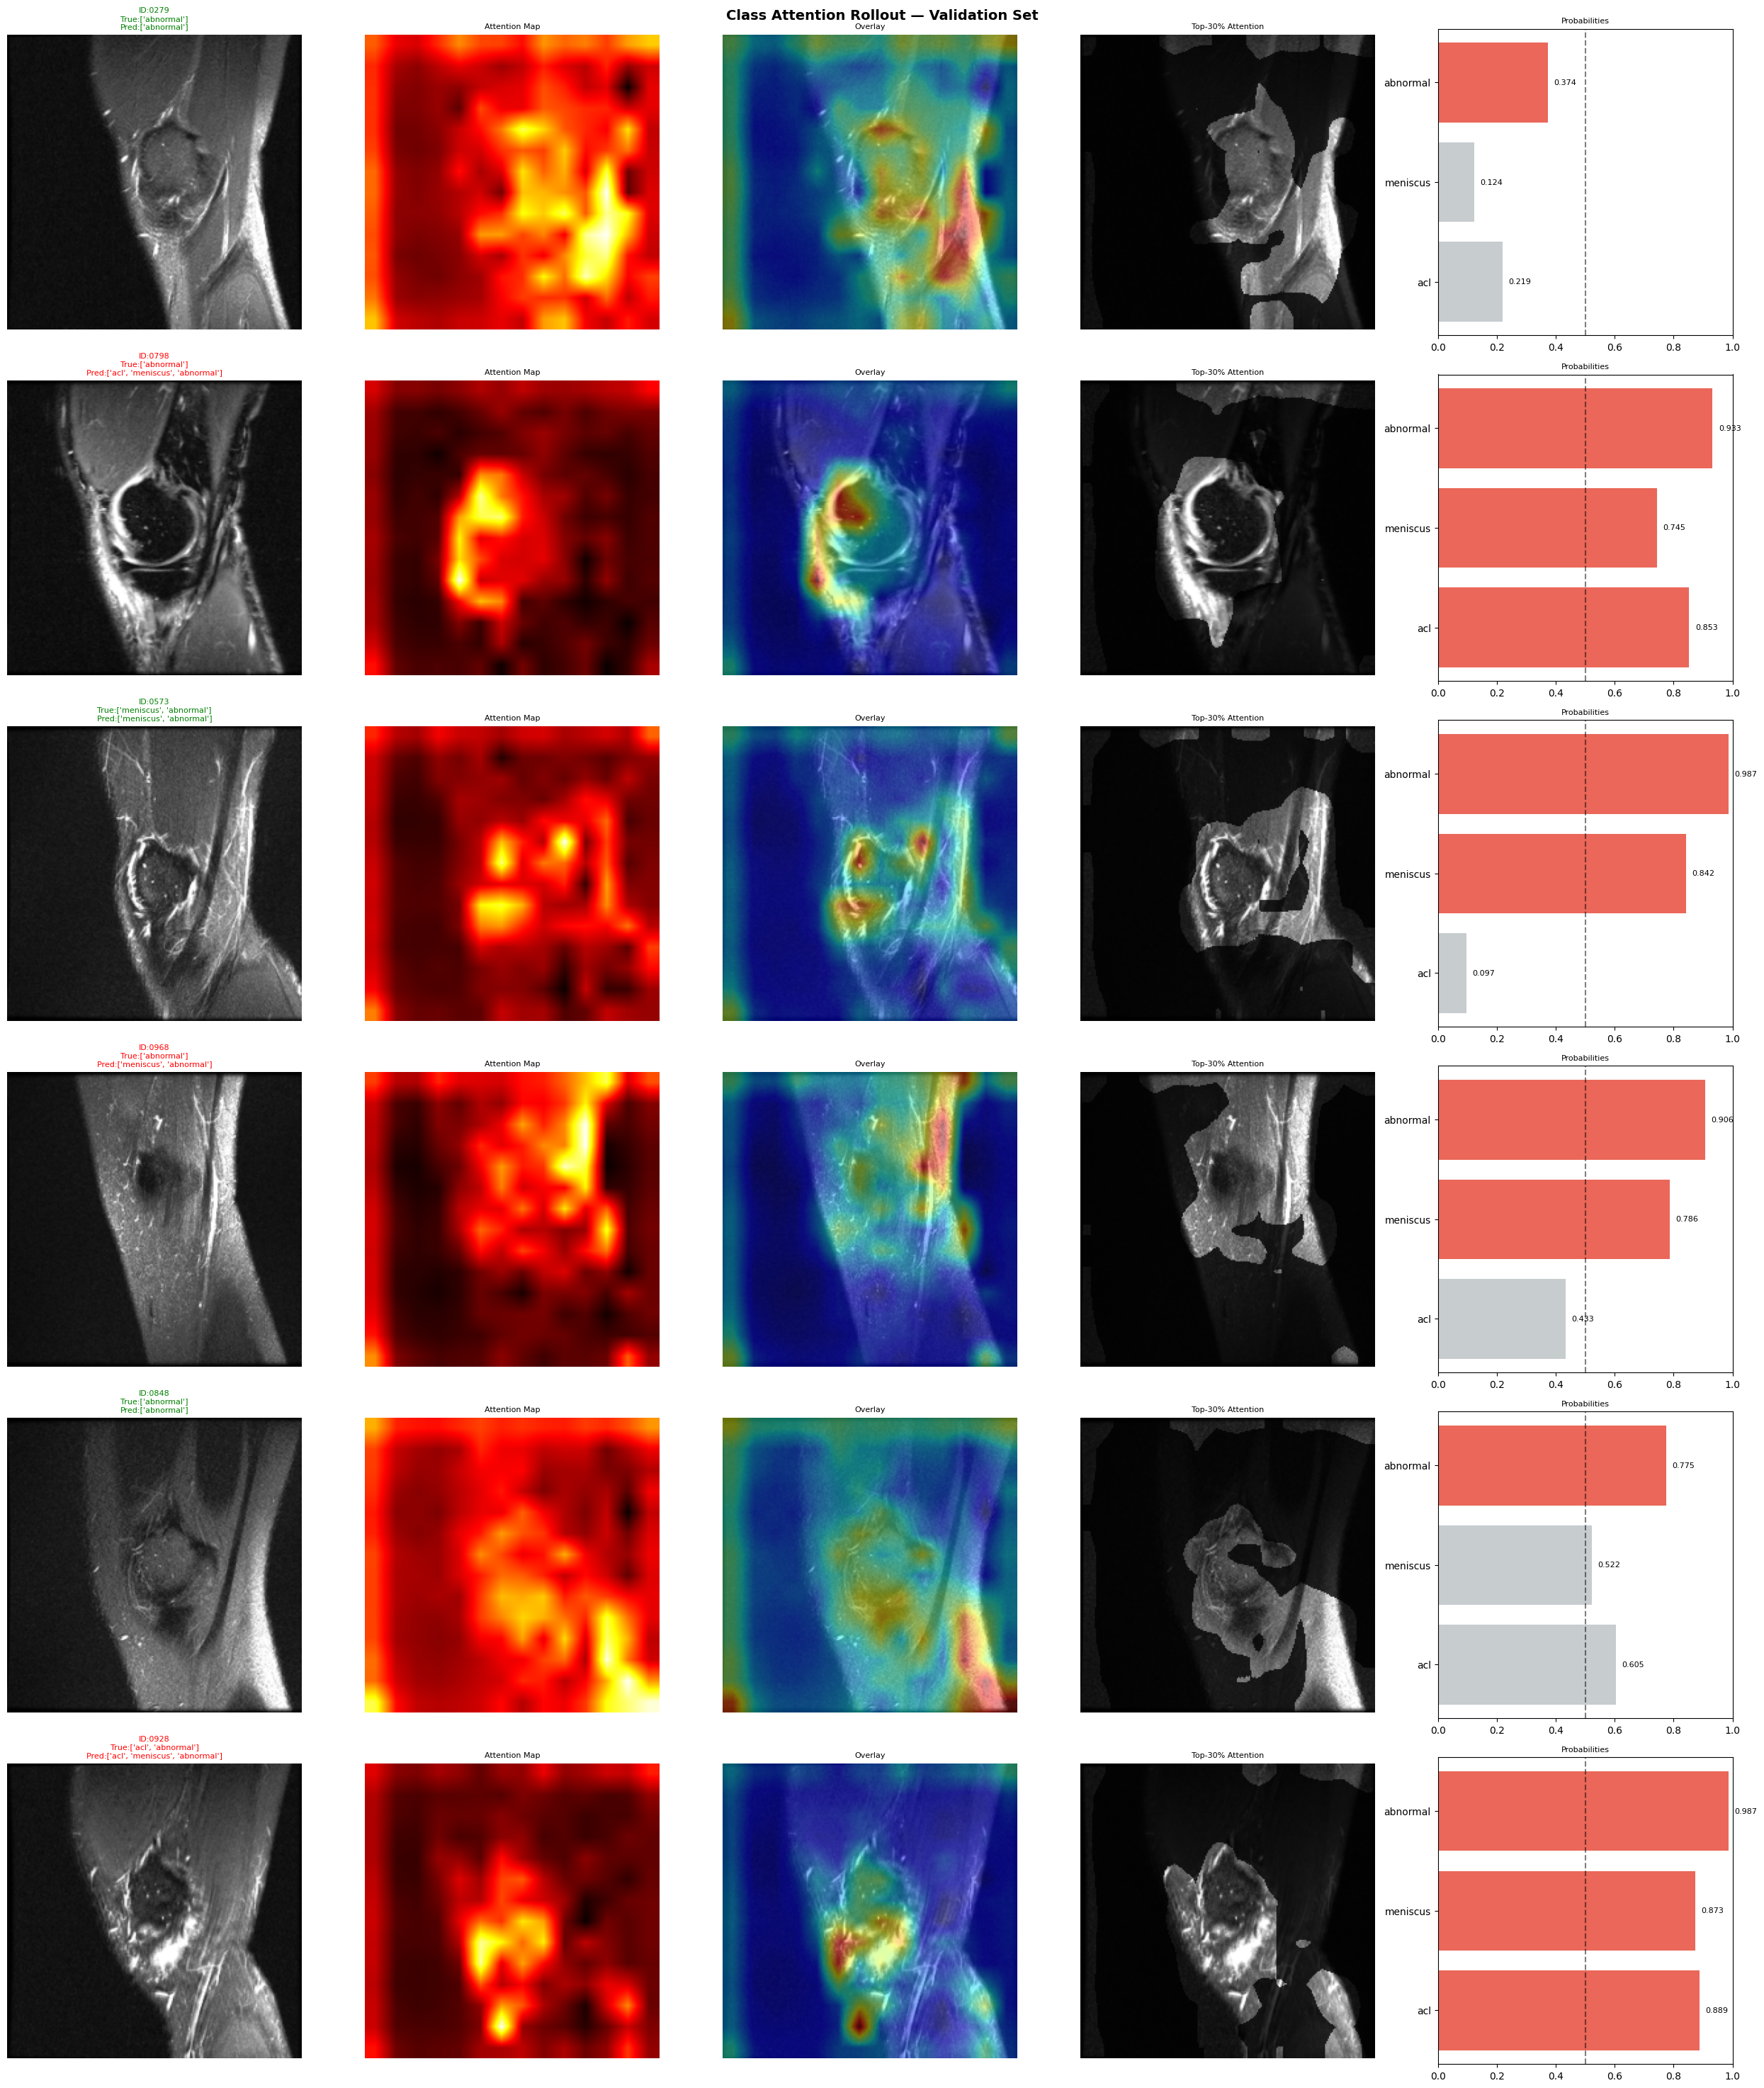

Saved → /user/HS402/mi00806/Downloads/AML/mrnet_outputs/attention_maps.png


In [19]:
def get_attention_rollout(model, img_tensor, device):
    model.eval()
    for block in model.backbone.blocks: block.attn.fused_attn = False
    attn_list, hooks = [], []
    def make_hook():
        def hook(module, inp, out): attn_list.append(out.detach().cpu())
        return hook
    for block in model.backbone.blocks:
        hooks.append(block.attn.attn_drop.register_forward_hook(make_hook()))
    with torch.no_grad():
        _ = model.backbone(img_tensor.unsqueeze(0).to(device))
    for h in hooks: h.remove()
    for block in model.backbone.blocks: block.attn.fused_attn = True

    n = attn_list[0].shape[-1]
    R = torch.eye(n)
    for attn in attn_list:
        A = attn[0].mean(0) + torch.eye(n)
        A = A/A.sum(-1, keepdim=True)
        R = torch.matmul(A, R)
    cls = R[0,1:].numpy()
    g   = int(cls.shape[0]**0.5)
    cls = cls.reshape(g,g)
    return (cls-cls.min())/(cls.max()-cls.min()+1e-8)


def denorm(t):
    m = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    s = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t*s+m).clamp(0,1)


def plot_attention_maps(model, dataset, device, eval_threshs, n=6):
    model.eval()
    idxs = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(n, 5, figsize=(25,5*n))
    fig.suptitle("Class Attention Rollout — Validation Set",
                 fontsize=14, fontweight="bold")

    for ri, idx in enumerate(idxs):
        sag, cor, axi, tgt, eid = dataset[idx]
        with torch.no_grad():
            logits = model(sag.unsqueeze(0).to(device),
                           cor.unsqueeze(0).to(device),
                           axi.unsqueeze(0).to(device))
        probs  = torch.sigmoid(logits).cpu().numpy()[0]
        preds  = np.array([int(probs[i]>=eval_threshs[i]) for i in range(3)])
        true_l = [CFG.LABEL_NAMES[i] for i in range(3) if tgt[i]>0.5] or ["Normal"]
        pred_l = [CFG.LABEL_NAMES[i] for i in range(3) if preds[i]]    or ["Normal"]
        correct = sorted(true_l)==sorted(pred_l)

        attn = get_attention_rollout(model, sag, device)
        mid  = denorm(sag).permute(1,2,0).numpy()[:,:,1]

        axes[ri,0].imshow(mid, cmap="gray"); axes[ri,0].axis("off")
        axes[ri,0].set_title(f"ID:{eid}\nTrue:{true_l}\nPred:{pred_l}",
                              color="green" if correct else "red", fontsize=8)

        axes[ri,1].imshow(attn, cmap="hot", interpolation="bilinear")
        axes[ri,1].set_title("Attention Map", fontsize=8); axes[ri,1].axis("off")

        attn_up = np.array(Image.fromarray((attn*255).astype(np.uint8)).resize(
                           (CFG.IMAGE_SIZE,CFG.IMAGE_SIZE), Image.BILINEAR))/255.
        axes[ri,2].imshow(mid, cmap="gray")
        axes[ri,2].imshow(attn_up, cmap="jet", alpha=0.45)
        axes[ri,2].set_title("Overlay", fontsize=8); axes[ri,2].axis("off")

        mask = mid.copy(); mask[attn_up<np.percentile(attn_up,70)] *= 0.2
        axes[ri,3].imshow(mask, cmap="gray")
        axes[ri,3].set_title("Top-30% Attention", fontsize=8); axes[ri,3].axis("off")

        bc = ["#E74C3C" if probs[i]>=eval_threshs[i] else "#BDC3C7" for i in range(3)]
        axes[ri,4].barh(CFG.LABEL_NAMES, probs, color=bc, alpha=0.85)
        axes[ri,4].axvline(0.5, color="black", linestyle="--", alpha=0.5)
        for j,p in enumerate(probs):
            axes[ri,4].text(max(p+0.02,0.02), j, f"{p:.3f}", va="center", fontsize=8)
        axes[ri,4].set_xlim([0,1]); axes[ri,4].set_title("Probabilities", fontsize=8)

    plt.tight_layout()
    plt.savefig(CFG.OUT_DIR/"attention_maps.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {CFG.OUT_DIR/'attention_maps.png'}")


plot_attention_maps(model, valid_ds, CFG.DEVICE, eval_threshs, n=6)


## Section 15 — Internet Image Testing & Domain Shift

Tests the model on publicly available knee MRI images.
Add more URLs from Radiopaedia.org or OrthoInfo.aaos.org.


Source                                           ACL    MEN    ABN  Prediction
--------------------------------------------------------------------------------
  Coronal PD knee MRI                          0.647  0.623  0.807  ['abnormal']


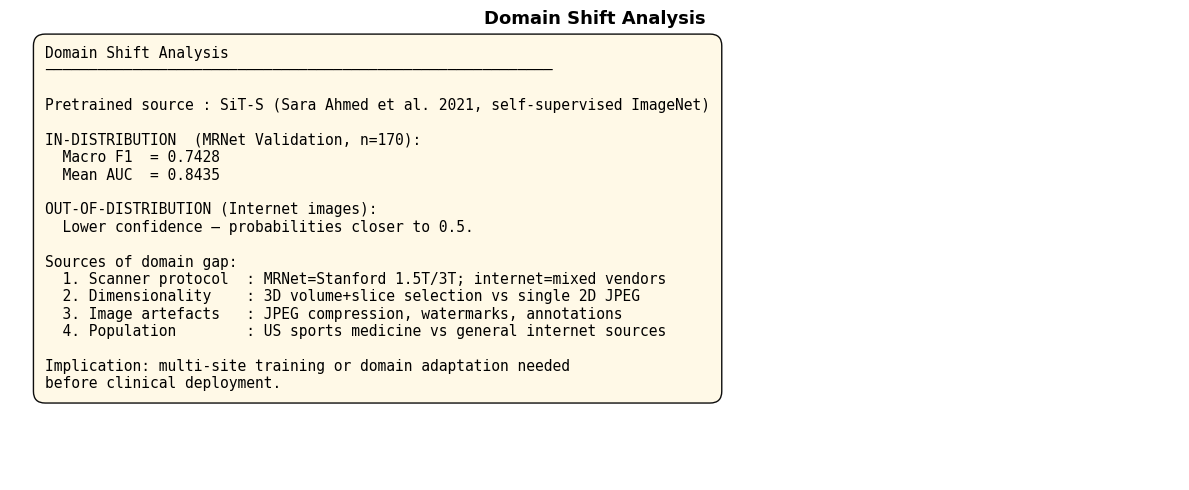

In [20]:
INTERNET_IMAGES = [
    {"url": "https://medality.com/wp-content/uploads/2024/07/Coronal20PD20FS200001.png",
     "label": "Coronal PD knee MRI"},
    # {"url": "YOUR_URL", "label": "ACL tear sagittal"},
]


def load_from_url(url, timeout=15):
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=timeout) as r:
            return Image.open(BytesIO(r.read())).convert("RGB")
    except Exception as e:
        print(f"  Could not load: {e}"); return None


@torch.no_grad()
def predict_single_image(model, pil_img, device, threshs):
    model.eval()
    t     = valid_tfm(pil_img).unsqueeze(0).to(device)
    probs = torch.sigmoid(model(t,t,t)).cpu().numpy()[0]
    preds = np.array([int(probs[i]>=threshs[i]) for i in range(3)])
    return probs, preds


print(f"{'Source':<45} {'ACL':>6} {'MEN':>6} {'ABN':>6}  Prediction")
print("-"*80)

for item in INTERNET_IMAGES:
    img = load_from_url(item["url"])
    if img is None: continue
    probs, preds = predict_single_image(model, img, CFG.DEVICE, eval_threshs)
    pred_l = [CFG.LABEL_NAMES[i] for i in range(3) if preds[i]] or ["Normal"]
    print(f"  {item['label']:<43} "
          f"{probs[0]:>6.3f} {probs[1]:>6.3f} {probs[2]:>6.3f}  {pred_l}")

# Domain shift summary
macro_f1 = f1_score(y_true, y_preds, average="macro", zero_division=0)
mean_auc  = np.mean([roc_auc_score(y_true[:,i], y_probs[:,i]) for i in range(3)])

fig, ax = plt.subplots(figsize=(12,5)); ax.axis("off")
text = (
    "Domain Shift Analysis\n" + "─"*58 + "\n\n"
    f"Pretrained source : {model.pretrained_source}\n\n"
    f"IN-DISTRIBUTION  (MRNet Validation, n={len(valid_df)}):\n"
    f"  Macro F1  = {macro_f1:.4f}\n"
    f"  Mean AUC  = {mean_auc:.4f}\n\n"
    "OUT-OF-DISTRIBUTION (Internet images):\n"
    "  Lower confidence — probabilities closer to 0.5.\n\n"
    "Sources of domain gap:\n"
    "  1. Scanner protocol  : MRNet=Stanford 1.5T/3T; internet=mixed vendors\n"
    "  2. Dimensionality    : 3D volume+slice selection vs single 2D JPEG\n"
    "  3. Image artefacts   : JPEG compression, watermarks, annotations\n"
    "  4. Population        : US sports medicine vs general internet sources\n\n"
    "Implication: multi-site training or domain adaptation needed\n"
    "before clinical deployment."
)
ax.text(0.03, 0.97, text, transform=ax.transAxes, fontsize=10.5, va="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.8", facecolor="#FFF9E6", alpha=0.95))
ax.set_title("Domain Shift Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(CFG.OUT_DIR/"domain_shift.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 16 — Final Results Summary

In [21]:
total_params = sum(p.numel() for p in model.parameters())
print("="*70)
print("  FINAL RESULTS")
print("="*70)
print(f"  Model             : ViT-Small patch16/224")
print(f"  Total parameters  : {total_params:,}")
print(f"  Pretrained source : {model.pretrained_source}")
print(f"  Loss              : FocalBCE  γ={CFG.FOCAL_GAMMA}  α={CFG.FOCAL_ALPHA}")
print(f"  MixUp             : α={CFG.MIXUP_ALPHA}  from ep {CFG.MIXUP_START_EP}")
print(f"  Unfreeze schedule : ep{CFG.UNFREEZE_PARTIAL_EP} "
      f"TOP{CFG.N_BLOCKS_PARTIAL} → ep{CFG.UNFREEZE_FULL_EP} FULL")
print(f"  Val thresholds    : " +
      "  ".join(f"{CFG.LABEL_NAMES[i]}@{eval_threshs[i]:.2f}" for i in range(3)))
print()
print(summary_df.to_string(index=False, float_format="{:.4f}".format))
print()
print("Output files:")
for f in sorted(list(CFG.OUT_DIR.glob("*.png")) +
                list(CFG.OUT_DIR.glob("*.csv")) +
                list(CFG.OUT_DIR.glob("*.pth"))):
    print(f"  {f.name:<35} {f.stat().st_size/1e6:.1f} MB")


  FINAL RESULTS
  Model             : ViT-Small patch16/224
  Total parameters  : 22,390,403
  Pretrained source : SiT-S (Sara Ahmed et al. 2021, self-supervised ImageNet)
  Loss              : FocalBCE  γ=0.5  α=[0.82, 0.63, 0.19]
  MixUp             : α=0.2  from ep 6
  Unfreeze schedule : ep5 TOP6 → ep10 FULL
  Val thresholds    : acl@0.85  meniscus@0.70  abnormal@0.20

Condition Threshold  Accuracy  Sensitivity  Specificity  Precision  F1-Score  AUC-ROC
      ACL      0.85    0.8647       0.6522       0.8980     0.5000    0.5660   0.8459
 MENISCUS      0.70    0.7412       0.8986       0.6337     0.6263    0.7381   0.8373
 ABNORMAL      0.20    0.8706       0.9781       0.4242     0.8758    0.9241   0.8474
MACRO AVG         -    0.8255       0.8429       0.6520     0.6674    0.7428   0.8435

Output files:
  attention_maps.png                  5.3 MB
  best_vit.pth                        89.6 MB
  confusion_matrices.png              0.1 MB
  domain_shift.png                    0.1 M